<a href="https://colab.research.google.com/github/amna-alii/CV-Lab01/blob/main/Lab03_Edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 03: Edge Detection Techniques and Their Impact on Classification Performance

##  Setup and configuration

In [1]:
import os, time, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix)
import tensorflow as tf
from tensorflow.keras import layers, models
warnings.filterwarnings("ignore"); tf.get_logger().setLevel("ERROR")


DATASET_DIR      = "path/to/your/dataset"
SELECTED_CLASSES = None
MAX_PER_CLASS    = 300
IMG_SIZE         = 64
VIS_SIZE         = 256
EPOCHS           = 15
BATCH_SIZE       = 32
SEED             = 42

BEST_FILTER = {"method": "gaussian", "ksize": 5, "sigma": 1.0}
BEST_CANNY  = None

DEMO_MODE = False


OUT = Path("lab03_outputs"); (OUT/"figures").mkdir(parents=True, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "image.cmap": "gray"})
EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

## b. Upload the dataset zip

In [2]:
import zipfile, shutil
from pathlib import Path

UPLOAD_ZIP = True
EXTRACT_TO = Path("dataset_extracted")
_IMG = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def find_dataset_root(base):
    """Return the folder that DIRECTLY contains the class folders (each holding images)."""
    cands = []
    for d in [Path(base)] + [p for p in Path(base).rglob("*") if p.is_dir()]:
        if "__MACOSX" in d.parts: continue
        cls = [s for s in d.iterdir() if s.is_dir() and not s.name.startswith(".")
               and any(f.suffix.lower() in _IMG for f in s.iterdir() if f.is_file())]
        if len(cls) >= 2: cands.append((d, len(cls)))
    if not cands: raise RuntimeError("No folder with >=2 class sub-folders of images found - check the zip structure.")
    print("Candidate dataset roots:"); [print("  ", d, f"({n} classes)") for d, n in cands]
    train = [c for c in cands if c[0].name.lower() in ("train", "training")]
    return (train or sorted(cands, key=lambda c: (-c[1], len(c[0].parts))))[0][0]

if UPLOAD_ZIP and not DEMO_MODE:
    from google.colab import files
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    if EXTRACT_TO.exists(): shutil.rmtree(EXTRACT_TO)
    with zipfile.ZipFile(zip_name) as z: z.extractall(EXTRACT_TO)
    base_src = find_dataset_root(EXTRACT_TO)
    DATASET_DIR = str(base_src)
    print("\nDataset root found at:", base_src)
    for c in sorted(p for p in base_src.iterdir() if p.is_dir()):
        print(f"  {c.name:25s} {sum(f.suffix.lower() in _IMG for f in c.rglob('*'))} images")
    if SELECTED_CLASSES:
        missing = [c for c in SELECTED_CLASSES if not (base_src/c).exists()]
        assert not missing, f"SELECTED_CLASSES not found as folders: {missing}"

Saving archive (4).zip to archive (4).zip
Candidate dataset roots:
   dataset_extracted/Split_smol/train (9 classes)
   dataset_extracted/Split_smol/val (9 classes)

Dataset root found at: dataset_extracted/Split_smol/train
  Actinic keratosis         80 images
  Atopic Dermatitis         81 images
  Benign keratosis          80 images
  Dermatofibroma            80 images
  Melanocytic nevus         80 images
  Melanoma                  80 images
  Squamous cell carcinoma   80 images
  Tinea Ringworm Candidiasis 56 images
  Vascular lesion           80 images


## 1. Image loading

In [3]:
def make_demo_dataset(root, n=120, size=128):
    """Synthetic shapes dataset – ONLY to test the pipeline."""
    rng = np.random.default_rng(0); root = Path(root)
    for cls in ["circles", "squares", "triangles", "stripes"]:
        (root/cls).mkdir(parents=True, exist_ok=True)
        for i in range(n):
            im = np.full((size, size), rng.integers(30, 120), np.uint8)
            col = int(rng.integers(150, 255)); cx, cy = rng.integers(40, 88, 2); r = int(rng.integers(20, 34))
            if cls == "circles":   cv2.circle(im, (int(cx), int(cy)), r, col, -1)
            elif cls == "squares": cv2.rectangle(im, (int(cx)-r, int(cy)-r), (int(cx)+r, int(cy)+r), col, -1)
            elif cls == "triangles":
                cv2.fillPoly(im, [np.array([[cx, cy-r], [cx-r, cy+r], [cx+r, cy+r]], np.int32)], col)
            else:
                for k in range(0, size, 16): cv2.line(im, (0, k), (size, k), col, 3)
            im = np.clip(im + rng.normal(0, 6, im.shape), 0, 255).astype(np.uint8)
            cv2.imwrite(str(root/cls/f"{cls}_{i:03d}.png"), im)

if DEMO_MODE:
    DATASET_DIR = "demo_dataset"; make_demo_dataset(DATASET_DIR)
    print("!!! DEMO_MODE ON – synthetic data, results are NOT valid for submission !!!")
assert Path(DATASET_DIR).exists(), f"DATASET_DIR '{DATASET_DIR}' not found – edit the configuration cell."

def list_files(root, classes=None, max_per_class=None):
    root = Path(root)
    classes = classes or sorted(d.name for d in root.iterdir() if d.is_dir())
    rng = random.Random(SEED); files, labels = [], []
    for ci, c in enumerate(classes):
        fs = sorted(p for p in (root/c).rglob("*") if p.suffix.lower() in EXT)
        rng.shuffle(fs); fs = fs[:max_per_class] if max_per_class else fs
        files += fs; labels += [ci]*len(fs)
    return files, np.array(labels), classes

def load_gray(files, size):
    out = []
    for f in files:
        im = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        out.append(cv2.resize(im, (size, size), interpolation=cv2.INTER_AREA))
    return np.array(out, np.uint8)

files, y_all, CLASSES = list_files(DATASET_DIR, SELECTED_CLASSES, MAX_PER_CLASS)
print("Classes:", CLASSES); print("Images per class:", dict(zip(CLASSES, np.bincount(y_all))))
X_raw = load_gray(files, IMG_SIZE)          # Set A (raw, grayscale, IMG_SIZE)
print("X_raw:", X_raw.shape)

Classes: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']
Images per class: {'Actinic keratosis': np.int64(80), 'Atopic Dermatitis': np.int64(81), 'Benign keratosis': np.int64(80), 'Dermatofibroma': np.int64(80), 'Melanocytic nevus': np.int64(80), 'Melanoma': np.int64(80), 'Squamous cell carcinoma': np.int64(80), 'Tinea Ringworm Candidiasis': np.int64(56), 'Vascular lesion': np.int64(80)}
X_raw: (697, 64, 64)


## 2. Filters, noise and edge detectors

In [4]:
# ---------- noise ----------
def gaussian_noise(img, sigma=25, seed=0):
    r = np.random.default_rng(seed)
    return np.clip(img.astype(np.float64) + r.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)

def salt_pepper(img, amount=0.05, seed=0):
    r = np.random.default_rng(seed); out = img.copy(); m = r.random(img.shape)
    out[m < amount/2] = 0; out[m > 1 - amount/2] = 255
    return out

# ---------- filters ----------
def gaussian_filter(img, ksize=5, sigma=1.0): return cv2.GaussianBlur(img, (ksize, ksize), sigma)
def median_filter(img, ksize=3):              return cv2.medianBlur(img, ksize)
def apply_filter(img, cfg):
    m = cfg["method"]
    if m == "gaussian":  return gaussian_filter(img, cfg.get("ksize", 5), cfg.get("sigma", 1.0))
    if m == "median":    return median_filter(img, cfg.get("ksize", 3))
    if m == "bilateral": return cv2.bilateralFilter(img, cfg.get("d", 9), cfg.get("sigmaColor", 75), cfg.get("sigmaSpace", 75))
    raise ValueError(m)

# ---------- edge detectors (continuous responses) ----------
PREWITT_X = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], np.float64); PREWITT_Y = PREWITT_X.T
def sobel_gx(img):  return cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
def sobel_gy(img):  return cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
def sobel_mag(img): return np.hypot(sobel_gx(img), sobel_gy(img))
def prewitt_mag(img):
    return np.hypot(cv2.filter2D(img, cv2.CV_64F, PREWITT_X), cv2.filter2D(img, cv2.CV_64F, PREWITT_Y))
def laplacian(img): return np.abs(cv2.Laplacian(img, cv2.CV_64F, ksize=3))
def log_edge(img, sigma=1.4):
    k = int(2*np.ceil(3*sigma) + 1)
    return np.abs(cv2.Laplacian(cv2.GaussianBlur(img, (k, k), sigma), cv2.CV_64F, ksize=3))
def canny(img, low=50, high=150, ksize=5):
    """Canny with an explicit Gaussian smoothing step of size ksize x ksize (OpenCV's Canny has none built in)."""
    return cv2.Canny(cv2.GaussianBlur(img, (ksize, ksize), 0), low, high)

def to_binary(resp):
    """Normalise a continuous response to 0-255 and threshold it with Otsu -> boolean edge map."""
    m8 = cv2.normalize(np.abs(resp), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    t, _ = cv2.threshold(m8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return m8 > t

RESPONSE = {"Sobel": sobel_mag, "Prewitt": prewitt_mag, "Laplacian": laplacian, "LoG": log_edge}
def edge_map(name, img, **kw):
    """Boolean edge map for a named detector."""
    if name == "Canny": return canny(img, **kw) > 0
    return to_binary(RESPONSE[name](img))
DETECTORS = ["Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]

# ---------- quantitative edge measures ----------
def edge_stats(pred, ref=None, tol=1):
    """density, fragmentation and (if a reference edge map is given) precision/recall/F1 with +-tol px tolerance."""
    s = {"n_edge_px": int(pred.sum()), "density": pred.mean(),
         "fragments_per_1k_px": cv2.connectedComponents(pred.astype(np.uint8), connectivity=8)[0] / max(pred.sum(), 1) * 1000}
    if ref is not None:
        k = np.ones((2*tol+1, 2*tol+1), np.uint8)
        pd_, rd_ = cv2.dilate(pred.astype(np.uint8), k) > 0, cv2.dilate(ref.astype(np.uint8), k) > 0
        p = (pred & rd_).sum() / max(pred.sum(), 1); r = (ref & pd_).sum() / max(ref.sum(), 1)
        s.update(precision=p, recall=r, f1=2*p*r/max(p+r, 1e-9))
    return s

## Task 1 – Comparative edge detection

6 sample images from classes: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis']


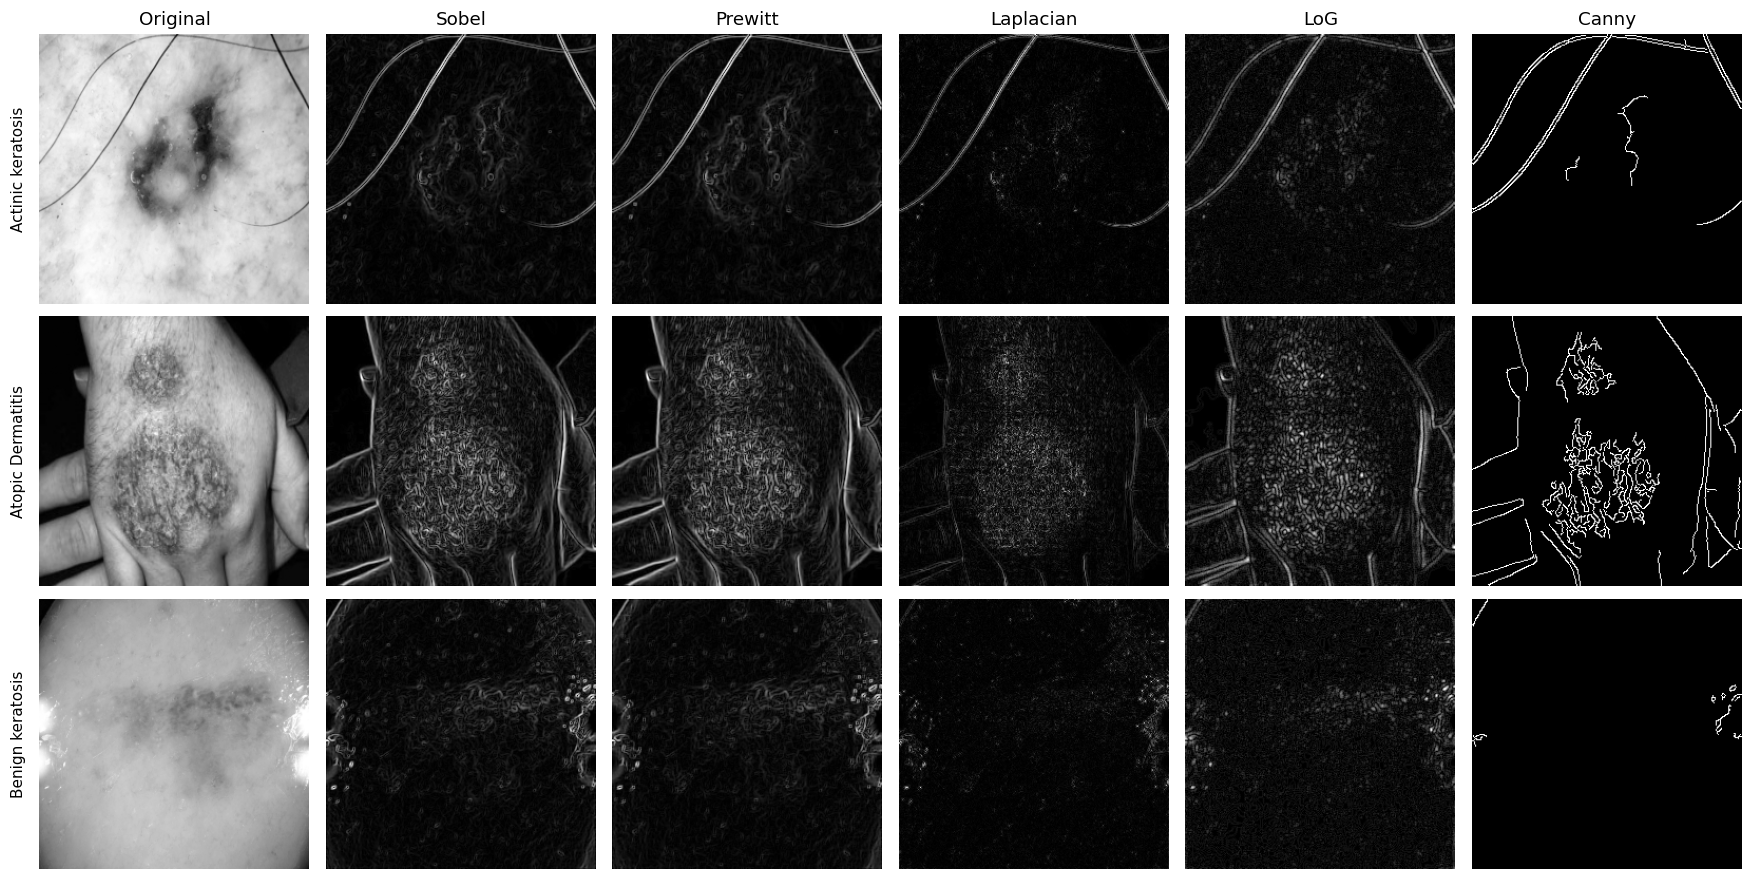

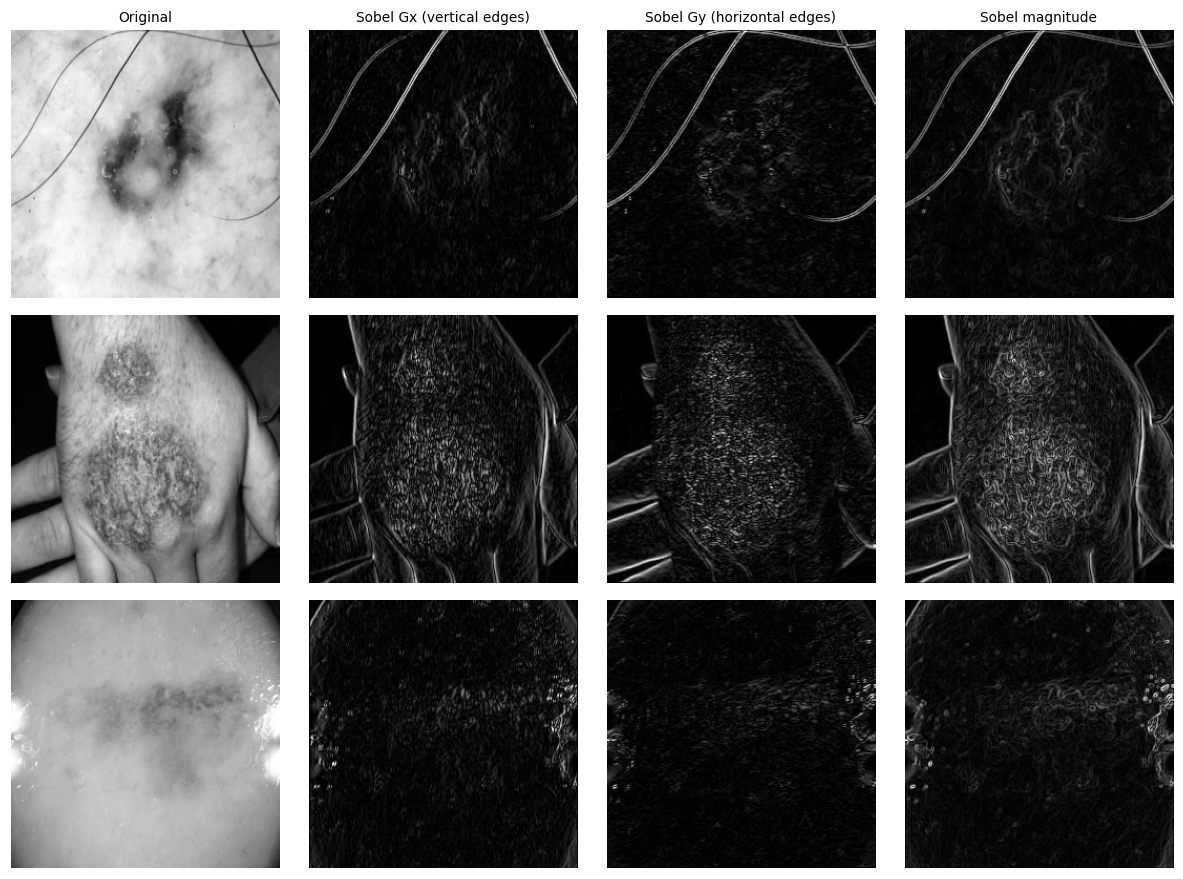

In [5]:
rng = random.Random(1)
sample_cls = list(range(min(3, len(CLASSES))))
sample_files = []
for ci in sample_cls:
    idx = [i for i, l in enumerate(y_all) if l == ci]; sample_files += [files[i] for i in rng.sample(idx, min(2, len(idx)))]
sample_labels = [CLASSES[y_all[files.index(f)]] for f in sample_files]
VIS = load_gray(sample_files, VIS_SIZE)
print(len(VIS), "sample images from classes:", sorted(set(sample_labels)))

# Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny  (one row per class)
show = [0, 2, 4] if len(VIS) >= 5 else list(range(len(VIS)))
fig, ax = plt.subplots(len(show), 6, figsize=(16, 2.7*len(show)))
ax = np.atleast_2d(ax)
for r, i in enumerate(show):
    im = VIS[i]
    outs = [im, sobel_mag(im), prewitt_mag(im), laplacian(im), log_edge(im), canny(im, 50, 150, 5)]
    for c, (o, t) in enumerate(zip(outs, ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"])):
        ax[r, c].imshow(o); ax[r, c].axis("off")
        ax[r, c].set_title(t if r == 0 else "")
    ax[r, 0].text(-0.05, 0.5, sample_labels[i], transform=ax[r, 0].transAxes, rotation=90, va="center", ha="right")
plt.tight_layout(); plt.savefig(OUT/"figures/task1_required_figure.png", bbox_inches="tight"); plt.show()

# Sobel Gx / Gy / magnitude
fig, ax = plt.subplots(len(show), 4, figsize=(11, 2.7*len(show))); ax = np.atleast_2d(ax)
for r, i in enumerate(show):
    im = VIS[i]
    for c, (o, t) in enumerate(zip([im, np.abs(sobel_gx(im)), np.abs(sobel_gy(im)), sobel_mag(im)],
                                   ["Original", "Sobel Gx (vertical edges)", "Sobel Gy (horizontal edges)", "Sobel magnitude"])):
        ax[r, c].imshow(o); ax[r, c].axis("off"); ax[r, c].set_title(t if r == 0 else "", fontsize=9)
plt.tight_layout(); plt.savefig(OUT/"figures/task1_sobel_gx_gy_mag.png", bbox_inches="tight"); plt.show()

## Task 2 – Effect of noise on edge detection (Table 1)

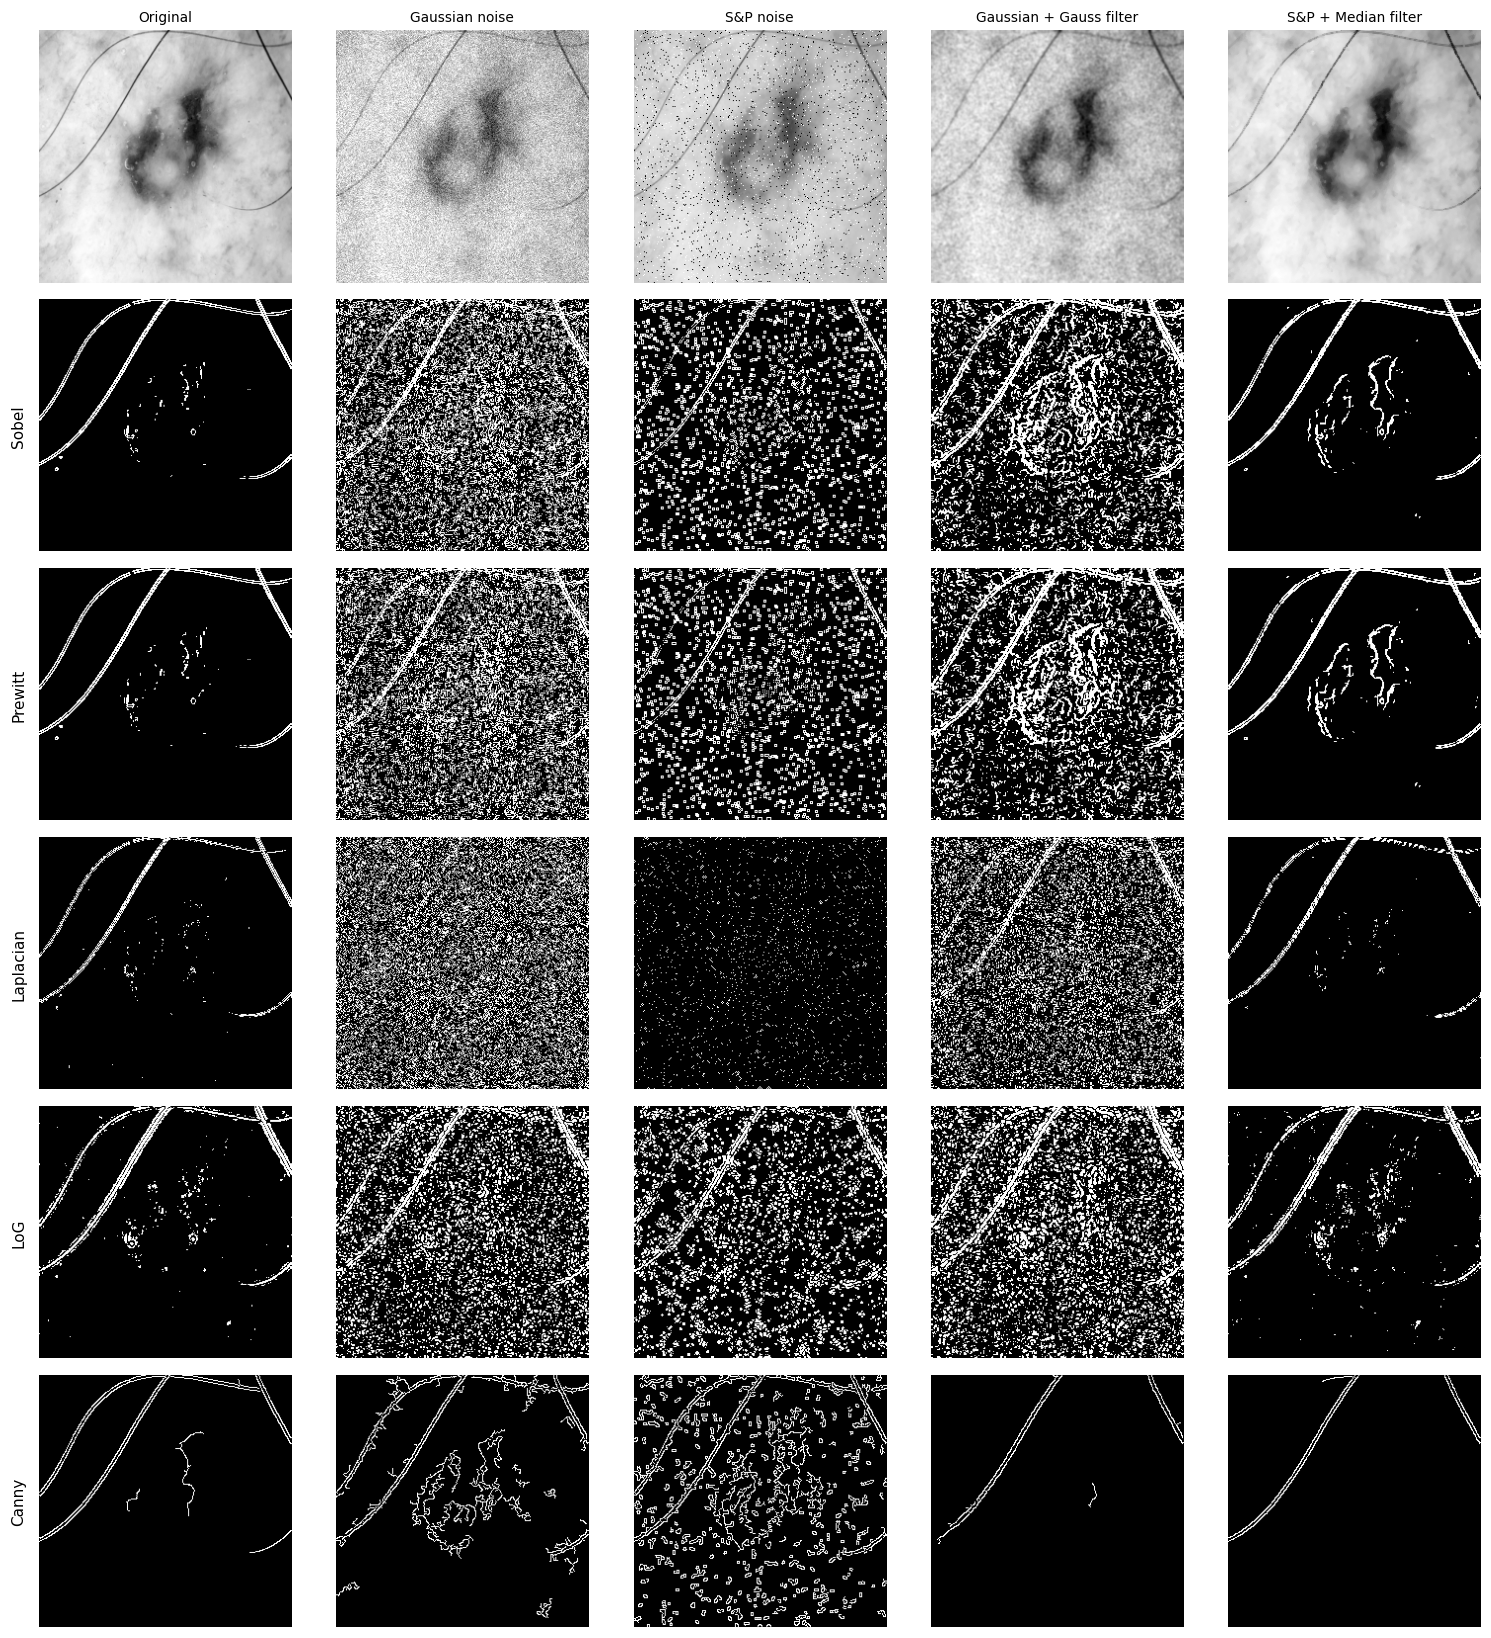

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,Reference,—,"Clean-image edges: density 10.5%, 35 fragments/1k edge px (lower = more continuous)."
1,Sobel,Noisy,Gaussian,None,Poor,High,"F1 vs clean edges 0.40; false edges 71%, missed/broken edges 1%; edge density x3.47 of clean; 52 fragments/1k px."
2,Sobel,Noisy,Salt & Pepper,None,Poor,High,"F1 vs clean edges 0.37; false edges 72%, missed/broken edges 16%; edge density x2.32 of clean; 58 fragments/1k px."
3,Sobel,Noisy,Gaussian,Gaussian Filter,Moderate,High,"F1 vs clean edges 0.50; false edges 61%, missed/broken edges 4%; edge density x2.79 of clean; 64 fragments/1k px."
4,Sobel,Noisy,Salt & Pepper,Median Filter,Good,Low,"F1 vs clean edges 0.96; false edges 4%, missed/broken edges 5%; edge density x1.00 of clean; 26 fragments/1k px."
5,Prewitt,Original,None,None,Reference,—,"Clean-image edges: density 10.7%, 34 fragments/1k edge px (lower = more continuous)."
6,Laplacian,Original,None,None,Reference,—,"Clean-image edges: density 7.1%, 175 fragments/1k edge px (lower = more continuous)."
7,LoG,Noisy,Gaussian,Gaussian Filter,Moderate,High,"F1 vs clean edges 0.55; false edges 55%, missed/broken edges 6%; edge density x2.24 of clean; 115 fragments/1k px."
8,Canny,Original,None,Built-in smoothing,Reference,—,"Clean-image edges: density 2.0%, 183 fragments/1k edge px (lower = more continuous)."
9,Canny,Noisy,Gaussian,Gaussian Filter,Moderate,Low,"F1 vs clean edges 0.46; false edges 44%, missed/broken edges 61%; edge density x0.63 of clean; 344 fragments/1k px."


Edge-map F1 vs clean edges (1.0 = identical to clean):


,Gaussian noise,S&P noise,Gaussian + Gauss filter,S&P + Median filter
Sobel,0.400,0.371,0.503,0.956
Prewitt,0.406,0.376,0.513,0.956
Laplacian,0.355,0.245,0.396,0.843
LoG,0.535,0.510,0.554,0.943
Canny,0.342,0.214,0.455,0.679


Most noise-sensitive detector: Gaussian noise -> Canny;  Salt & Pepper -> Canny


In [6]:
CONDITIONS = {  # name: (noise label, preprocessing label, function image -> input image)
    "Original":               ("None", "None",            lambda im: im),
    "Gaussian noise":         ("Gaussian", "None",        lambda im: gaussian_noise(im, 25)),
    "S&P noise":              ("Salt & Pepper", "None",   lambda im: salt_pepper(im, 0.05)),
    "Gaussian + Gauss filter":("Gaussian", "Gaussian Filter", lambda im: gaussian_filter(gaussian_noise(im, 25), 5, 1.0)),
    "S&P + Median filter":    ("Salt & Pepper", "Median Filter", lambda im: median_filter(salt_pepper(im, 0.05), 3)),
}
# --- figure: one image, every detector x every condition
im0 = VIS[0]
fig, ax = plt.subplots(len(DETECTORS)+1, len(CONDITIONS), figsize=(14, 2.5*(len(DETECTORS)+1)))
for c, (cn, (_, _, fn)) in enumerate(CONDITIONS.items()):
    inp = fn(im0); ax[0, c].imshow(inp); ax[0, c].set_title(cn, fontsize=9); ax[0, c].axis("off")
    for r, d in enumerate(DETECTORS, 1):
        ax[r, c].imshow(edge_map(d, inp)); ax[r, c].axis("off")
        if c == 0: ax[r, c].text(-0.05, 0.5, d, transform=ax[r, c].transAxes, rotation=90, va="center", ha="right")
plt.tight_layout(); plt.savefig(OUT/"figures/task2_noise_edge_grid.png", bbox_inches="tight"); plt.show()

# --- measurements averaged over all sample images (reference = same detector on the clean image)
def measure(det, cond):
    rows = []
    for im in VIS:
        ref = edge_map(det, im); pred = edge_map(det, CONDITIONS[cond][2](im))
        s = edge_stats(pred, ref); s["ref_density"] = ref.mean(); rows.append(s)
    return pd.DataFrame(rows).mean()

def label_quality(f1):  return "Good" if f1 >= 0.75 else "Moderate" if f1 >= 0.45 else "Poor"
def label_sens(ratio):  return "Low" if ratio < 1.3 else "Medium" if ratio < 2.0 else "High"

T1_ROWS = [("Sobel","Original"),("Sobel","Gaussian noise"),("Sobel","S&P noise"),("Sobel","Gaussian + Gauss filter"),
           ("Sobel","S&P + Median filter"),("Prewitt","Original"),("Laplacian","Original"),("LoG","Gaussian + Gauss filter"),
           ("Canny","Original"),("Canny","Gaussian + Gauss filter"),("Canny","S&P + Median filter")]
t1 = []
for det, cond in T1_ROWS:
    m = measure(det, cond); noise, pre, _ = CONDITIONS[cond]
    if cond == "Original":
        q, sens = "Reference", "—"
        obs = f"Clean-image edges: density {m.density:.1%}, {m.fragments_per_1k_px:.0f} fragments/1k edge px (lower = more continuous)."
        if det == "Canny": pre = "Built-in smoothing"
    else:
        ratio = m.density / max(m.ref_density, 1e-9); q, sens = label_quality(m.f1), label_sens(ratio)
        obs = (f"F1 vs clean edges {m.f1:.2f}; false edges {1-m.precision:.0%}, missed/broken edges {1-m.recall:.0%}; "
               f"edge density x{ratio:.2f} of clean; {m.fragments_per_1k_px:.0f} fragments/1k px.")
    t1.append({"Edge Detector": det, "Input Image": "Original" if cond=="Original" else "Noisy", "Noise Type": noise,
               "Preprocessing": pre, "Edge Quality": q, "Noise Sensitivity": sens, "Observations": obs})
table1 = pd.DataFrame(t1); table1.to_csv(OUT/"table1_noise_effect.csv", index=False)
pd.set_option("display.max_colwidth", 200, "display.width", 250); display(table1)

# --- extra: detector x condition F1 matrix (supports Discussion Q1/Q2)
f1_mat = pd.DataFrame({cn: {d: measure(d, cn).get("f1", np.nan) for d in DETECTORS} for cn in list(CONDITIONS)[1:]}).round(3)
f1_mat.to_csv(OUT/"table1b_f1_matrix.csv"); print("Edge-map F1 vs clean edges (1.0 = identical to clean):"); display(f1_mat)
worst_g = f1_mat["Gaussian noise"].idxmin(); worst_sp = f1_mat["S&P noise"].idxmin()
print(f"Most noise-sensitive detector: Gaussian noise -> {worst_g};  Salt & Pepper -> {worst_sp}")

## Task 3 – Canny parameter analysis (Table 2)

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges (px/img),Edge density,Fragments/1k px,Noise robustness (F1 under Gaussian noise),"Val accuracy (RF, IMG_SIZE)",Observation
0,Canny-1,30,100,3x3,Balanced,3472,5.3%,23.4,0.26,0.333,Many edge pixels (5.3% of image); kernel 3x3 keeps more fine detail.
1,Canny-2,50,150,3x3,Balanced,1884,2.9%,23.5,0.18,0.343,Fewer edge pixels (2.9% of image); kernel 3x3 keeps more fine detail.
2,Canny-3,100,200,3x3,Under-detected (misses weak edges),892,1.4%,190.7,0.32,0.343,Fewer edge pixels (1.4% of image); kernel 3x3 keeps more fine detail.
3,Canny-4,50,150,5x5,Balanced,1311,2.0%,182.8,0.34,0.352,Fewer edge pixels (2.0% of image); kernel 5x5 suppresses more fine texture/noise.
4,Canny-5 (extra),30,100,5x5,Balanced,2416,3.7%,23.8,0.22,0.295,Fewer edge pixels (3.7% of image); kernel 5x5 suppresses more fine texture/noise.
5,Canny-6 (extra),100,200,5x5,Under-detected (misses weak edges),509,0.8%,192.6,0.55,0.324,Fewer edge pixels (0.8% of image); kernel 5x5 suppresses more fine texture/noise.


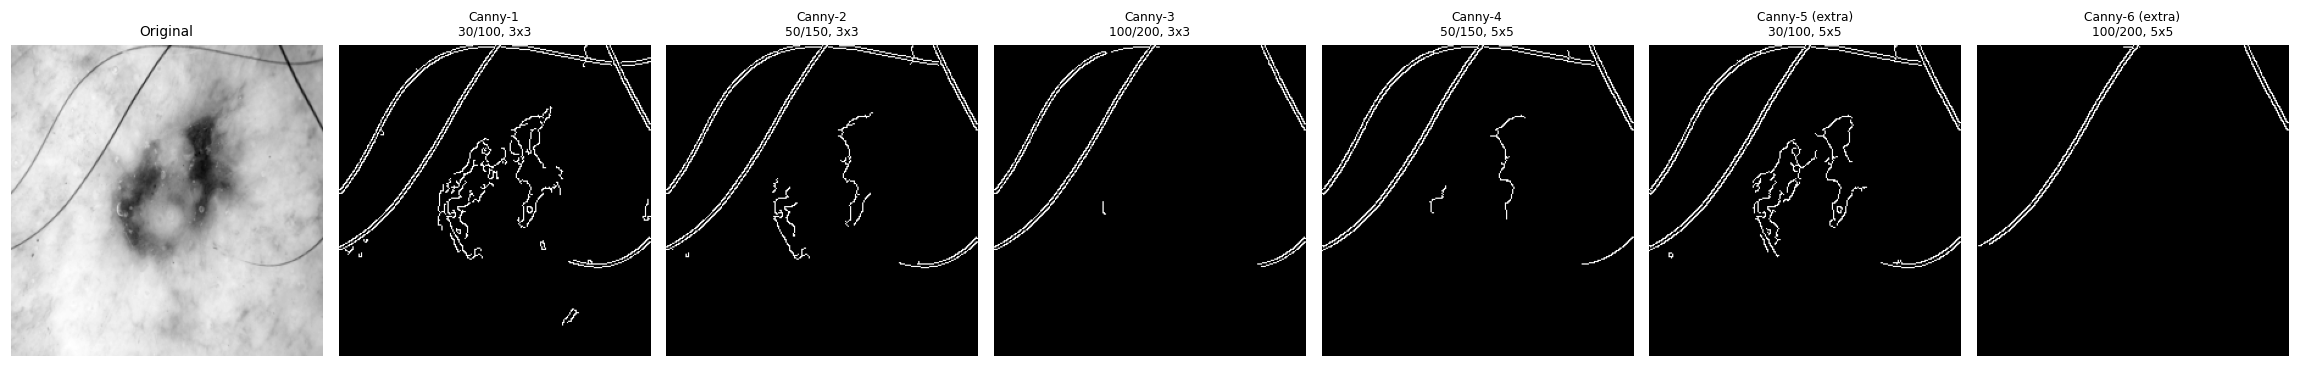

Auto-selected best Canny config: Canny-4 -> low/high/kernel = (50, 150, 5)


In [7]:
CANNY_CFGS = [("Canny-1", 30, 100, 3), ("Canny-2", 50, 150, 3), ("Canny-3", 100, 200, 3),
              ("Canny-4", 50, 150, 5), ("Canny-5 (extra)", 30, 100, 5), ("Canny-6 (extra)", 100, 200, 5)]

# quick data-driven check at classification resolution: Random-Forest accuracy on a validation split
_idx = np.arange(len(X_raw))
_tr, _tmp = train_test_split(_idx, test_size=0.30, stratify=y_all, random_state=SEED)
_va, _te = train_test_split(_tmp, test_size=0.50, stratify=y_all[_tmp], random_state=SEED)   # SAME split reused in Task 4
def canny_set(X, lo, hi, k): return np.array([canny(x, lo, hi, k) > 0 for x in X], np.float32)
def quick_val_acc(lo, hi, k):
    Xe = canny_set(X_raw, lo, hi, k).reshape(len(X_raw), -1)
    rf = RandomForestClassifier(100, n_jobs=-1, random_state=SEED).fit(Xe[_tr], y_all[_tr])
    return accuracy_score(y_all[_va], rf.predict(Xe[_va]))

t2 = []
for name, lo, hi, k in CANNY_CFGS:
    ms, rob = [], []
    for im in VIS:
        e = canny(im, lo, hi, k) > 0; ms.append(edge_stats(e))
        rob.append(edge_stats(canny(gaussian_noise(im, 25), lo, hi, k) > 0, e)["f1"])
    m = pd.DataFrame(ms).mean(); dens = m.density
    q = "Under-detected (misses weak edges)" if dens < 0.02 else "Over-detected (cluttered, texture/noise edges)" if dens > 0.12 else "Balanced"
    t2.append({"Configuration": name, "Low Threshold": lo, "High Threshold": hi, "Kernel Size": f"{k}x{k}", "Edge Quality": q,
               "Number of Detected Edges (px/img)": int(m.n_edge_px), "Edge density": f"{dens:.1%}",
               "Fragments/1k px": round(m.fragments_per_1k_px, 1), "Noise robustness (F1 under Gaussian noise)": round(float(np.mean(rob)), 2),
               "Val accuracy (RF, IMG_SIZE)": round(quick_val_acc(lo, hi, k), 3),
               "Observation": f"{'Fewer' if dens<0.05 else 'Many'} edge pixels ({dens:.1%} of image); kernel {k}x{k} "
                              f"{'suppresses more fine texture/noise' if k==5 else 'keeps more fine detail'}."})
table2 = pd.DataFrame(t2); table2.to_csv(OUT/"table2_canny_params.csv", index=False); display(table2)

fig, ax = plt.subplots(1, len(CANNY_CFGS)+1, figsize=(3*(len(CANNY_CFGS)+1), 3.3))
ax[0].imshow(VIS[0]); ax[0].set_title("Original", fontsize=9); ax[0].axis("off")
for a, (n, lo, hi, k) in zip(ax[1:], CANNY_CFGS):
    a.imshow(canny(VIS[0], lo, hi, k)); a.set_title(f"{n}\n{lo}/{hi}, {k}x{k}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.savefig(OUT/"figures/task3_canny_params.png", bbox_inches="tight"); plt.show()

if BEST_CANNY is None:
    b = table2.sort_values("Val accuracy (RF, IMG_SIZE)", ascending=False).iloc[0]
    BEST_CANNY = (int(b["Low Threshold"]), int(b["High Threshold"]), int(b["Kernel Size"][0]))
    print(f"Auto-selected best Canny config: {b['Configuration']} -> low/high/kernel = {BEST_CANNY}")
else: print("Using manually set BEST_CANNY =", BEST_CANNY)

## Task 4 – Prepare the three datasets (A raw, B filtered, C edge)

{'Raw (Lab 1)': (697, 64, 64), 'Filtered (Lab 2)': (697, 64, 64), 'Edge (Lab 3)': (697, 64, 64)} | train/val/test = 487 105 105


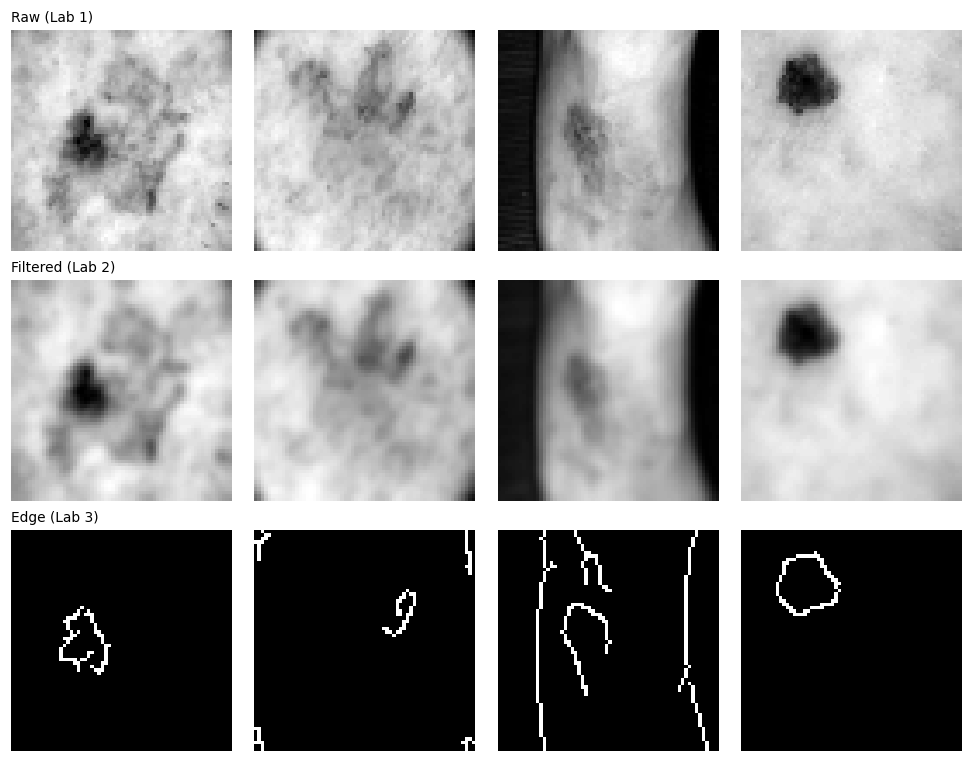

In [8]:
y_tr, y_va, y_te = y_all[_tr], y_all[_va], y_all[_te]      # identical split for all three sets
X_filt = np.array([apply_filter(x, BEST_FILTER) for x in X_raw])
X_edge = canny_set(X_raw, *BEST_CANNY)
SETS = {"Raw (Lab 1)": X_raw.astype(np.float32)/255., "Filtered (Lab 2)": X_filt.astype(np.float32)/255., "Edge (Lab 3)": X_edge}
print({k: v.shape for k, v in SETS.items()}, "| train/val/test =", len(_tr), len(_va), len(_te))

fig, ax = plt.subplots(3, 4, figsize=(9, 7))
for c in range(4):
    j = _te[c*max(1, len(_te)//4)]
    for r, (n, X) in enumerate(SETS.items()):
        ax[r, c].imshow(X[j]); ax[r, c].axis("off")
        if c == 0: ax[r, c].set_title(n, fontsize=9, loc="left")
plt.tight_layout(); plt.savefig(OUT/"figures/task4_three_datasets.png", bbox_inches="tight"); plt.show()

## Task 5 – Train and evaluate all models on all three datasets (Table 3)

In [9]:
NC = len(CLASSES)
def cnn1():
    return models.Sequential([layers.Input((IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(), layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Flatten(), layers.Dense(64, activation="relu"), layers.Dropout(0.3), layers.Dense(NC, activation="softmax")])
def cnn2():
    m = models.Sequential([layers.Input((IMG_SIZE, IMG_SIZE, 1))])
    for f in (32, 64, 128):
        m.add(layers.Conv2D(f, 3, padding="same", activation="relu")); m.add(layers.BatchNormalization())
        m.add(layers.Conv2D(f, 3, padding="same", activation="relu")); m.add(layers.MaxPooling2D()); m.add(layers.Dropout(0.25))
    m.add(layers.GlobalAveragePooling2D()); m.add(layers.Dense(64, activation="relu")); m.add(layers.Dropout(0.4))
    m.add(layers.Dense(NC, activation="softmax")); return m

MODELS = {
    "SVM": lambda: SVC(kernel="rbf", C=10, gamma="scale"),
    "Random Forest": lambda: RandomForestClassifier(200, n_jobs=-1, random_state=SEED),
    "KNN": lambda: KNeighborsClassifier(5),
    "CNN Model 1": cnn1, "CNN Model 2": cnn2}

def run(model_name, set_name, X):
    Xtr, Xva, Xte = X[_tr], X[_va], X[_te]
    if model_name.startswith("CNN"):
        tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
        m = MODELS[model_name](); m.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
        t0 = time.perf_counter()
        m.fit(Xtr[..., None], y_tr, validation_data=(Xva[..., None], y_va), epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        train_s = time.perf_counter() - t0
        m.predict(Xte[:BATCH_SIZE, ..., None], verbose=0)                    # warm-up
        t0 = time.perf_counter(); prob = m.predict(Xte[..., None], batch_size=BATCH_SIZE, verbose=0); inf = time.perf_counter() - t0
        pred = prob.argmax(1)
    else:
        m = MODELS[model_name](); f = lambda a: a.reshape(len(a), -1)
        t0 = time.perf_counter(); m.fit(f(Xtr), y_tr); train_s = time.perf_counter() - t0
        t0 = time.perf_counter(); pred = m.predict(f(Xte)); inf = time.perf_counter() - t0
    p, r, f1, _ = precision_recall_fscore_support(y_te, pred, average="macro", zero_division=0)
    return dict(Model=model_name, Set=set_name, Accuracy=accuracy_score(y_te, pred), Precision=p, Recall=r, F1=f1,
                Train_s=train_s, Infer_ms=inf/len(Xte)*1000, pred=pred)

results = []
for mn in MODELS:
    for sn, X in SETS.items():
        res = run(mn, sn, X); results.append(res)
        print(f"{mn:14s} | {sn:17s} | acc {res['Accuracy']:.3f}  F1 {res['F1']:.3f}  train {res['Train_s']:.1f}s  infer {res['Infer_ms']:.3f} ms/img")
res_df = pd.DataFrame(results).drop(columns="pred"); res_df.to_csv(OUT/"table3_full_all_metrics.csv", index=False)

SVM            | Raw (Lab 1)       | acc 0.505  F1 0.505  train 0.6s  infer 1.924 ms/img
SVM            | Filtered (Lab 2)  | acc 0.533  F1 0.532  train 0.5s  infer 2.247 ms/img
SVM            | Edge (Lab 3)      | acc 0.324  F1 0.295  train 0.7s  infer 1.779 ms/img
Random Forest  | Raw (Lab 1)       | acc 0.410  F1 0.399  train 2.9s  infer 0.513 ms/img
Random Forest  | Filtered (Lab 2)  | acc 0.429  F1 0.415  train 2.9s  infer 0.525 ms/img
Random Forest  | Edge (Lab 3)      | acc 0.324  F1 0.267  train 1.0s  infer 0.520 ms/img
KNN            | Raw (Lab 1)       | acc 0.390  F1 0.385  train 0.0s  infer 0.603 ms/img
KNN            | Filtered (Lab 2)  | acc 0.400  F1 0.395  train 0.0s  infer 0.157 ms/img
KNN            | Edge (Lab 3)      | acc 0.162  F1 0.089  train 0.0s  infer 0.150 ms/img
CNN Model 1    | Raw (Lab 1)       | acc 0.467  F1 0.455  train 10.0s  infer 3.247 ms/img
CNN Model 1    | Filtered (Lab 2)  | acc 0.495  F1 0.472  train 8.9s  infer 3.310 ms/img
CNN Model 1    | Edg

In [10]:
# ---- Table 3 in the exact layout requested.
# Accuracy is given for all three sets; Precision/Recall/F1/Time are macro-averaged on the TEST set of the best set for that model.
acc = res_df.pivot(index="Model", columns="Set", values="Accuracy").reindex(list(MODELS))
best_set = acc.idxmax(axis=1)
rows = []
for mn in MODELS:
    b = res_df[(res_df.Model == mn) & (res_df.Set == best_set[mn])].iloc[0]
    rows.append({"Model / Classifier": mn, "Accuracy Raw (Lab 1)": acc.loc[mn, "Raw (Lab 1)"],
                 "Accuracy Filtered (Lab 2)": acc.loc[mn, "Filtered (Lab 2)"], "Accuracy Edge (Lab 3)": acc.loc[mn, "Edge (Lab 3)"],
                 "Precision": b.Precision, "Recall": b.Recall, "F1-Score": b.F1, "Training Time (s)": b.Train_s,
                 "Inference Time (ms/img)": b.Infer_ms, "P/R/F1/time from set": best_set[mn]})
table3 = pd.DataFrame(rows).round(3); table3.to_csv(OUT/"table3_cross_lab.csv", index=False); display(table3)
print("Full per-set metrics are in table3_full_all_metrics.csv (report P/R/F1/time for every set there if your instructor wants it).")

,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms/img),P/R/F1/time from set
0,SVM,0.505,0.533,0.324,0.540,0.531,0.532,0.543,2.247,Filtered (Lab 2)
1,Random Forest,0.410,0.429,0.324,0.423,0.420,0.415,2.939,0.525,Filtered (Lab 2)
2,KNN,0.390,0.400,0.162,0.456,0.395,0.395,0.001,0.157,Filtered (Lab 2)
3,CNN Model 1,0.467,0.495,0.333,0.490,0.490,0.472,8.914,3.310,Filtered (Lab 2)
4,CNN Model 2,0.076,0.076,0.114,0.013,0.111,0.023,19.402,7.740,Edge (Lab 3)


Full per-set metrics are in table3_full_all_metrics.csv (report P/R/F1/time for every set there if your instructor wants it).


## Task 6 – Visual comparison for the best-performing model

Best-performing model (highest test accuracy on any set): SVM


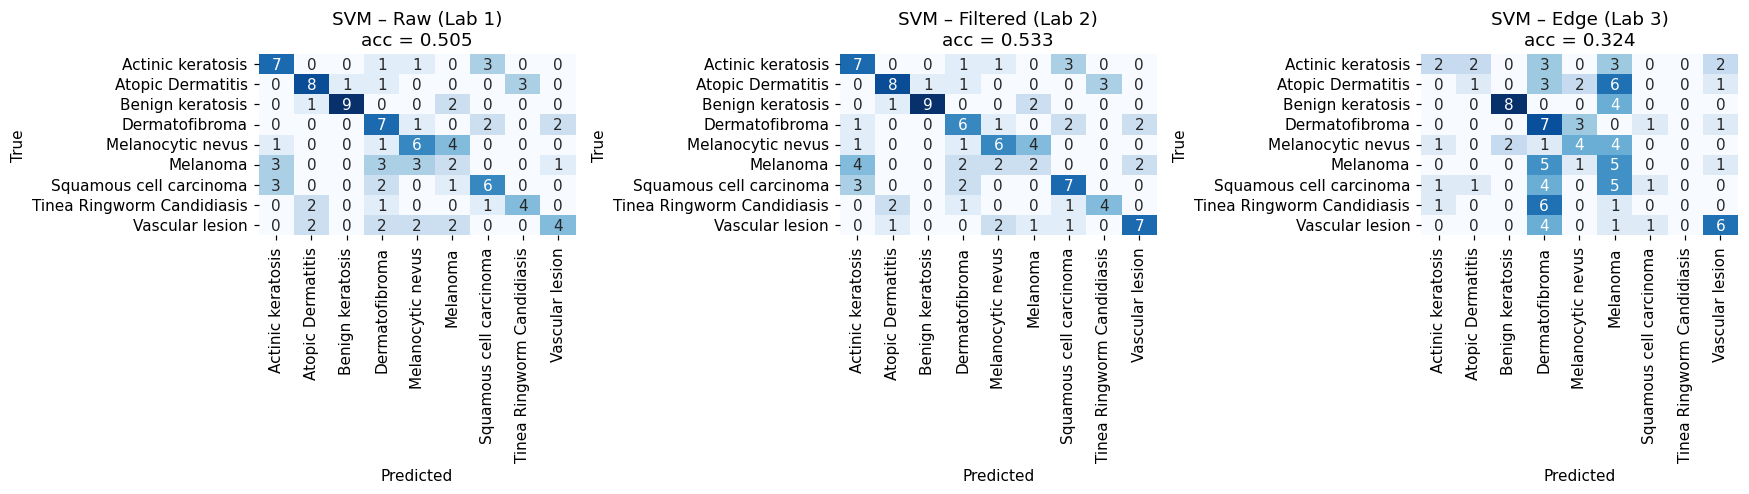

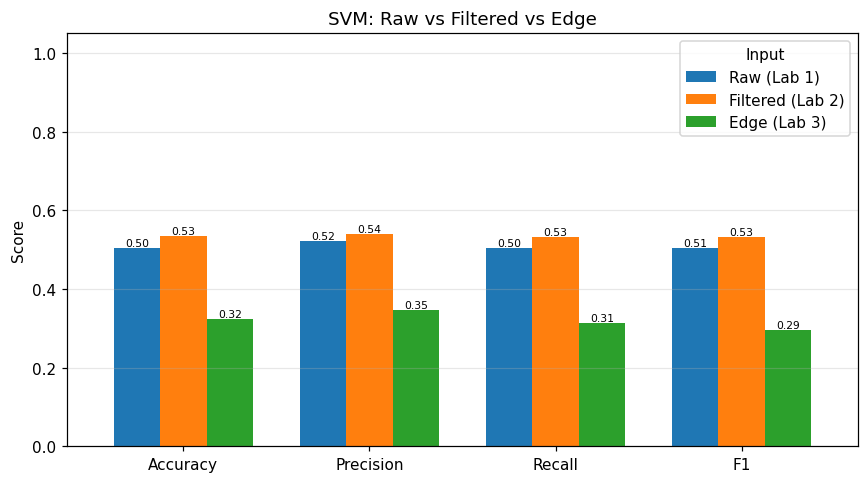

,Accuracy,Precision,Recall,F1
Set,,,,
Edge (Lab 3),0.251,0.229,0.245,0.199
Filtered (Lab 2),0.387,0.384,0.390,0.366
Raw (Lab 1),0.370,0.371,0.373,0.352


Accuracy change of EDGE vs RAW per model (percentage points):
Model
SVM             -18.1
Random Forest    -8.6
KNN             -22.9
CNN Model 1     -13.3
CNN Model 2       3.8

Best representation on average: Filtered (Lab 2)


In [11]:
best = res_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
print("Best-performing model (highest test accuracy on any set):", best)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for a, sn in zip(ax, SETS):
    pr = next(r["pred"] for r in results if r["Model"] == best and r["Set"] == sn)
    cm = confusion_matrix(y_te, pr, labels=range(NC))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=a, xticklabels=CLASSES, yticklabels=CLASSES)
    a.set_title(f"{best} – {sn}\nacc = {accuracy_score(y_te, pr):.3f}"); a.set_xlabel("Predicted"); a.set_ylabel("True")
plt.tight_layout(); plt.savefig(OUT/"figures/task6_confusion_matrices.png", bbox_inches="tight"); plt.show()

sub = res_df[res_df.Model == best].set_index("Set")[["Accuracy", "Precision", "Recall", "F1"]]
ax = sub.T.plot(kind="bar", figsize=(8, 4.5), rot=0, width=0.75); ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title(f"{best}: Raw vs Filtered vs Edge"); ax.legend(title="Input"); ax.grid(axis="y", alpha=.3)
for c in ax.containers: ax.bar_label(c, fmt="%.2f", fontsize=7)
plt.tight_layout(); plt.savefig(OUT/"figures/task6_metric_bars.png", bbox_inches="tight"); plt.show()

# average across all five models (supports Q4 and Q7)
avg = res_df.groupby("Set")[["Accuracy", "Precision", "Recall", "F1"]].mean().round(3); display(avg)
print("Accuracy change of EDGE vs RAW per model (percentage points):")
print(((acc["Edge (Lab 3)"] - acc["Raw (Lab 1)"])*100).round(1).to_string())
print("\nBest representation on average:", avg["Accuracy"].idxmax())

## Summary of numbers for the report
Run the cell below and copy the numbers into your discussion answers (Q1–Q7). The report cannot claim anything the tables above do not show.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [12]:
print("Q1  most noise-sensitive detector  -> Gaussian noise:", worst_g, "| Salt&Pepper:", worst_sp)
print("Q2  filtering gain (edge F1 vs clean):"); print(f1_mat.round(2).to_string())
print("Q3  Canny threshold effect:"); print(table2[["Configuration","Low Threshold","High Threshold","Kernel Size","Edge density","Fragments/1k px","Val accuracy (RF, IMG_SIZE)"]].to_string(index=False))
print("Q4/Q7  mean over models:"); print(avg.to_string())
print("\nAll files saved in:", OUT.resolve())

Q1  most noise-sensitive detector  -> Gaussian noise: Canny | Salt&Pepper: Canny
Q2  filtering gain (edge F1 vs clean):
           Gaussian noise  S&P noise  Gaussian + Gauss filter  S&P + Median filter
Sobel                0.40       0.37                     0.50                 0.96
Prewitt              0.41       0.38                     0.51                 0.96
Laplacian            0.36       0.24                     0.40                 0.84
LoG                  0.54       0.51                     0.55                 0.94
Canny                0.34       0.21                     0.46                 0.68
Q3  Canny threshold effect:
  Configuration  Low Threshold  High Threshold Kernel Size Edge density  Fragments/1k px  Val accuracy (RF, IMG_SIZE)
        Canny-1             30             100         3x3         5.3%             23.4                        0.333
        Canny-2             50             150         3x3         2.9%             23.5                        0.343
